### Sub-Question: 
How often does a state’s presidential party vote match the senator, house rep and governor party?

In [2]:
# Import necessary libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


 All four datatsets imported include the political party associated with each candidate that ran in the 2020 US elections, making them relevant dataset to the question.

In [3]:
#Import datasets
df_state = pd.read_csv("4-US_Election_2020/president_county_candidate.csv")
df_senator = pd.read_csv("4-US_Election_2020/senate_county_candidate.csv")
df_house = pd.read_csv("4-US_Election_2020/house_candidate.csv")
df_governor = pd.read_csv("4-US_Election_2020/governors_county_candidate.csv")

### Dataset Description
 The "governors_county_candidate" dataset shows state governor election results at the county-level. Each row, or observation, represents a candidate's results in a particular county. The variables include the state and county in which the cnadidate ran, candidate name, their affiliated political party, total votes the candidate received in that county, and whether they won in that specific county.

 Below is a table describing statistics for voter turnout per state

In [4]:
print(f"Number of rows and columns, repectively: {df_governor.shape}")
print(f"Number of States that elected new governors: {len(df_governor["state"].unique())}")
round(df_governor.groupby("state").describe(),2)



Number of rows and columns, repectively: (5145, 6)
Number of States that elected new governors: 11


votes                                                         \
                 count      mean       std    min      25%      50%       75%   
state                                                                           
Delaware          12.0  41052.92  56233.32  616.0  1216.25  21558.5  59763.50   
Indiana          276.0  10943.42  21503.98  323.0  1963.25   4113.5   9713.50   
Missouri         460.0   6548.42  23879.74    2.0    80.50    771.5   3814.25   
Montana          168.0   3592.78   8009.01    7.0   193.00    916.5   2561.25   
New Hampshire    948.0    836.29   2219.86    0.0     4.00     91.0    726.00   
North Carolina   400.0  13756.94  36445.54    6.0   141.75   2022.5  13304.50   
North Dakota     159.0   2139.13   5873.01   16.0   107.00    571.0   1455.00   
Utah             144.0  10131.10  36309.47    0.0   165.50    667.0   4022.00   
Vermont         2214.0    163.83    624.71    0.0     2.00      7.0     33.00   
Washington       117.0  34670.55  96678.90    4.0   296.00   6514.0  24366.00   
West Virginia    247.0   3148.13   5845.11    0.0   137.50    632.0   3294.50   

                          
                     max  
state                     
Delaware        191678.0  
Indiana         203475.0  
Missouri        317327.0  
Montana          48586.0  
New Hampshire    32454.0  
North Carolina  410386.0  
North Dakota     50649.0  
Utah            266177.0  
Vermont          10600.0  
Washington      887374.0  
West Virginia    41310.0

### Data Cleaning "house_candidate.csv"
The previous datasets separated the states and counties into separate columns, making it easy to determine winning candidates and their presidential parties. This dataset, however, only describes the district making it difficult to extract information at the state-level for each winning candidate. 

Below, I sort the districts into appropriate U.S. states and appended the resulting list as a new column labeled "States".

Each observation in the "house_candidate" describes voting results for a candidates in a particular district. Unlike the previous datasets, a state can elect more than one house representative. Winning in one district meant representing the state in the house. Additionally, the data is collected at the district-level, so I must clean it by adding a "State" column to group the districts into appropriate states.

In [5]:
#Adding column to assign districts into states
states_list = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California",
    "Colorado", "Connecticut", "Delaware", "Florida", "Georgia",
    "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland",
    "Massachusetts", "Michigan", "Minnesota", "Mississippi", "Missouri",
    "Montana", "Nebraska", "Nevada", "New Hampshire", "New Jersey",
    "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina",
    "South Dakota", "Tennessee", "Texas", "Utah", "Vermont",
    "West Virginia", "Washington", "Virginia", "Wisconsin", "Wyoming"
]
States = []

for district in df_house["district"]:
    for index in range(len(states_list)):
        if states_list[index] in district:
            States.append(states_list[index])
            break
    else:
        States.append("None")       

df_house["States"] = States




In [6]:
print(f"Number of rows and columns, repectively: {df_house.shape}")
print(f"Total number of winning house representatives: {len(df_house.query("won == True"))}")
round(df_house.groupby("States").describe(),2)

Number of rows and columns, repectively: (1215, 6)
Total number of winning house representatives: 436


total_votes                                                    \
                     count         mean          std        min          25%   
States                                                                         
Alabama               13.0    156400.69     96113.25      287.0    104595.00   
Alaska                 3.0    117721.67    102207.06     1183.0     80519.50   
Arizona               23.0    142097.78     91562.96       18.0     72910.00   
Arkansas               9.0    131044.00     85154.27     7668.0     75750.00   
California           106.0    157773.14     63446.49    34955.0     99855.75   
Colorado              30.0    105498.33    115950.51     1441.0      4331.25   
Connecticut           17.0    104244.65     91744.89       10.0      5052.00   
Delaware               4.0    122067.50    139287.41     3814.0      5965.00   
Florida               69.0    151666.45    101572.12        0.0     11703.00   
Georgia               36.0    135664.25     96887.56        0.0     65206.25   
Hawaii                 8.0     65816.88     76125.25      661.0      5504.50   
Idaho                  7.0    121414.43    121985.30     7940.0     12513.00   
Illinois              41.0    143332.24     79803.43        7.0     88559.00   
Indiana               23.0    130279.91     77908.86     9521.0     93397.00   
Iowa                   9.0    181894.44     67354.67    15361.0    196958.00   
Kansas                10.0    135895.30     77798.09    11596.0     92336.25   
Kentucky              21.0    100757.24    104584.46        0.0         7.00   
Louisiana             30.0     67386.70     80544.82     3017.0     10442.50   
Maine                  6.0    134700.50    110010.07       15.0     42850.25   
Maryland              18.0    163826.22     91244.93     1089.0    107795.50   
Massachusetts         26.0    127948.38    121578.61      361.0      3620.50   
Michigan              49.0    110664.65    101753.80     1974.0      5481.00   
Minnesota             23.0    138665.52     89063.31     6499.0     33758.00   
Mississippi           10.0    123699.90     98829.49      203.0     31755.00   
Missouri              25.0    118867.00    104239.57        4.0      9954.00   
Montana                2.0    300754.50     54326.31   262340.0    281547.25   
Nebraska               9.0    104588.67     85630.98     8938.0     10923.00   
Nevada                15.0     90373.80     85748.53     3750.0      9259.50   
New Hampshire          8.0     98367.75    100876.82       53.0      6860.00   
New Jersey            39.0    113664.69     99216.20     1172.0      3630.50   
New Mexico             7.0    129097.71     62585.68      117.0    126856.00   
New York             102.0     80629.98     88366.86       90.0      1169.50   
None                   3.0  50857439.33  41610274.68  2883083.0  37717027.50   
North Carolina        29.0    183604.31     93629.55     5503.0    132752.00   
North Dakota           3.0    118407.67    117938.19    12024.0     54997.00   
Ohio                  43.0    133989.30     91943.52       11.0     37007.50   
Oklahoma              13.0    119337.15     85118.37     8544.0     63472.00   
Oregon                15.0    153647.87    118440.82     6869.0     13367.00   
Pennsylvania          36.0    188347.47     65900.32    33671.0    140881.75   
Rhode Island           5.0     97257.40     62690.45    28300.0     35457.00   
South Carolina        17.0    147256.47     81710.49     2646.0     95712.00   
South Dakota           2.0    198866.00    174115.15    75748.0    137307.00   
Tennessee             28.0    101489.32     98424.75     1990.0      4930.25   
Texas                117.0     94787.11     84813.79        0.0      6594.00   
Utah                  16.0     89514.50     94418.74       29.0      7787.75   
Vermont                8.0     44354.88     85009.27      544.0      1914.75   
Virginia              22.0    195929.00     72020.03     9163.0    153450.00   
Washington     

[Additional Note]
Typically, there should only be a max of 435 house represenatives per election cycle. However, "house_candidate" includes a "United's 0th district" as an unassigned/error district. In a real election, these typical represent state-wide totals but aren't necessarily useful in practice. This 436th candidate doesn't really affect end-results, but if I care about the total winners then I can run the cell below:

In [7]:
placeholder_winner = df_house.query("(district == 'United States’s 0th district') and (won == True)").index

df_house.iloc[placeholder_winner, -2] = False

print(f"Total number of winning house representatives: {len(df_house.query("won == True"))}")
# 435 representatives

Total number of winning house representatives: 435


### Recoding statisitics for "president_county_candidate"
Computing statistics to find the overall political party of each state. This is computed through mass popular votes of each political party that ran in the state. 

In [8]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df_state.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["total_votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
state_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind, "Presidential_Party": winner})

display(state_proportions.round(2))





,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Presidential_Party
0,Alabama,0.37,0.62,0.01,REP
1,Alaska,0.39,0.49,0.12,REP
2,Arizona,0.49,0.49,0.02,DEM
3,Arkansas,0.35,0.62,0.03,REP
4,California,0.63,0.34,0.02,DEM
5,Colorado,0.55,0.42,0.03,DEM
6,Connecticut,0.59,0.39,0.02,DEM
7,Delaware,0.59,0.40,0.01,DEM
8,District of Columbia,0.92,0.05,0.02,DEM
9,Florida,0.48,0.51,0.01,REP


### Recoding statistics for "senate_county_president"
Computing statistics to determine the political party affiliated with the senator that won in each state. Essentialy same principle as "presidential_county_candidate" dataset but using a more direct method that involves finding specific candidate that won then extracting their political party rather than just finding overall political party that received the most votes. Once again, because the dataset was recorded at the county-level, I grouped by state and found the candidate amassing the most overall total votes across all counties in that one state. 

As a note, only 34 states elected new senators in the U.S. 2020 elections. 

In [9]:
sen_grouped = df_senator.groupby( ["state","candidate","party"] ).agg(state_vote = ('total_votes', 'sum'))

sen_grouped_reset = sen_grouped.reset_index()


sen_max_index = sen_grouped_reset.groupby("state")["state_vote"].idxmax()

senator_proportions = sen_grouped_reset.iloc[sen_max_index]
senator_proportions = senator_proportions.rename(columns = {"party" : "Senator_Party"})
senator_proportions = senator_proportions.rename(columns = {"state" : "State"})

senator_proportions

,State,candidate,Senator_Party,state_vote
1,Alabama,Doug Jones,DEM,595943
4,Alaska,Al Gross,DEM,86606
9,Arizona,Martha McSally,REP,1235512
10,Arkansas,Ricky Harrington,LIB,289905
13,Colorado,Cory Gardner,REP,737195
19,Delaware,Lauren Witzke,REP,118652
27,Georgia,David Perdue,REP,859492
48,Idaho,Paulette Jordan,DEM,263501
54,Illinois,Mark Curran,REP,1733395
59,Iowa,Theresa Greenfield,DEM,361332


### Recoding statistics for "governor_county_candidate"

Same method as first "presidential_county_candidate" dataset where I find the political party that received the most votes in each state. Each state only elects one governor. 

As a note, only 11 states participated in governor elections for this cycle. However, this can be misleading if we're comparing raw counts when looking at frequency of presidential party matches among all 50 states. 

In [10]:
states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []


for group in df_governor.groupby("state"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for votes, party in zip(state_data["votes"], state_data["party"]): #loops through "total_votes" and "party" for each state
        total = total + votes #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + votes
        elif party == "REP":
            rep = rep + votes
        else:
            ind = ind + votes
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)   

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
governor_proportions = pd.DataFrame({"State": states, "Governor_Party": winner})

display(governor_proportions)

,State,Governor_Party
0,Delaware,DEM
1,Indiana,REP
2,Missouri,REP
3,Montana,REP
4,New Hampshire,REP
5,North Carolina,DEM
6,North Dakota,REP
7,Utah,REP
8,Vermont,REP
9,Washington,DEM


### Recoding statistics for "house_candidate" after cleaning
Because there are multiple winners from each state, I determine the presidential party for each state using "House Majority," based on the political party that a majority of the winners align with. 

In the cell below, I find the proportion of democratic, republican, or independent (other) newly-elected house representatives for each state. The FOR loop takes data from the subset of winners. The party with a greater proportion becomes the overall presidential party for that state, as indicated in the "House_Majority" column.

Aggregate the winning candidates because I only care about those who actually became house representatives for their states.

In [11]:

house_winners_agg = df_house.query("won == True")

states = []
prop_dem = []
prop_rep = []
prop_ind = []
winner = []
total_reps = []

for group in house_winners_agg.groupby("States"): #groupby groups the data by state. group includes the state name and then all its associated data
    state_name = group[0] #grabs the state name of a group
    state_data = group[1] #grabs the data that corresponds to the state name
    states.append(state_name)

    total = 0 #total number of votes
    dem = 0 #number of democrats
    rep = 0 #number of republicans
    ind = 0 #number of independents
    prop_dems = 0 #proportion of democratic votes
    prop_reps = 0 #proportion of republican votes
    prop_inds = 0 #proportion of independent votes
    win = "no one" #party of the president the state voted for

    for party in state_data["party"]: #loops through "total_votes" and "party" for each state
        total = total + 1 #calculates total votes for each state
        if party == "DEM": #these statements count the number of democrat, republican and independent votes respectively
            dem = dem + 1
        elif party == "REP":
            rep = rep + 1
        else:
            ind = ind + 1
    
    prop_dems = dem/total #proportion of democratic votes
    prop_reps = rep/total #proportion of republican votes
    prop_inds = ind/total #proportion of independent votes

    prop_dem.append(prop_dems)
    prop_rep.append(prop_reps)
    prop_ind.append(prop_inds)  
    total_reps.append(total)

    if prop_dems > prop_reps and prop_dems > prop_inds: #these statements determine which party won
        win = "DEM"
    elif prop_reps > prop_dems and prop_reps > prop_inds:
        win = "REP"
    elif prop_dems == prop_reps:
        win = "TIE"
    else:
        win = "IND"

    winner.append(win)

#creates a new dataframe with the proportions of votes for each party and the winner for each state
house_proportions = pd.DataFrame({"State": states, "Proportion_Democrat": prop_dem, "Proportion_Republican":prop_rep, "Proportion_Independent": prop_ind,"Total_Reps": total_reps, "House_Majority": winner})

display(house_proportions)


,State,Proportion_Democrat,Proportion_Republican,Proportion_Independent,Total_Reps,House_Majority
0,Alabama,0.142857,0.857143,0.0,7,REP
1,Alaska,0.000000,1.000000,0.0,1,REP
2,Arizona,0.555556,0.444444,0.0,9,DEM
3,Arkansas,0.000000,1.000000,0.0,4,REP
4,California,0.792453,0.207547,0.0,53,DEM
5,Colorado,0.571429,0.428571,0.0,7,DEM
6,Connecticut,1.000000,0.000000,0.0,5,DEM
7,Delaware,1.000000,0.000000,0.0,1,DEM
8,Florida,0.407407,0.592593,0.0,27,REP
9,Georgia,0.428571,0.571429,0.0,14,REP


### Merging
Merge dataframe of overall presidential party, party of elected senator, party of elected governor, and majority party of elected house representatives for each state

In [12]:
#merge everything
state_senator = pd.merge(left = state_proportions[["State","Presidential_Party"]], 
    right = senator_proportions[["State", "Senator_Party"]], 
    how = "left", on = "State")

state_senator_house = pd.merge(left = state_senator, 
    right = house_proportions[["State", "House_Majority"]], 
    how = "left", on = "State")

merged = pd.merge(left = state_senator_house, 
    right = governor_proportions[["State", "Governor_Party"]], 
    how = "left", on = "State")


display(merged)

,State,Presidential_Party,Senator_Party,House_Majority,Governor_Party
0,Alabama,REP,DEM,REP,NaN
1,Alaska,REP,DEM,REP,NaN
2,Arizona,DEM,REP,DEM,NaN
3,Arkansas,REP,LIB,REP,NaN
4,California,DEM,NaN,DEM,NaN
5,Colorado,DEM,REP,DEM,NaN
6,Connecticut,DEM,NaN,DEM,NaN
7,Delaware,DEM,REP,DEM,DEM
8,District of Columbia,DEM,NaN,NaN,NaN
9,Florida,REP,NaN,REP,NaN


### Results: 
### Compute frequencies of political party matches across presidential, senate, governor, and house

I query variables from the the merged dataframe to identify states that have the same political party across their overall presidential, senate, house, and governor elections. To organize the data, I sorted all information into a table.

As mentioned before, the senate and governor datasets only included 34 and 11 participating states, respectively. Raw counts alone may be misleading, so I also calculated proportions. For example, among the 11 states that did elect new governors, what proportion of these align with the overall state presidential party? 

In [15]:
labels = [
    "President vs Senate",
    "President vs House Majority",
    "President vs Governor",
    "President vs Senate & House",
    "President vs Senate, House & Governor"
    ]

raw_counts = [
    len(merged.query("Presidential_Party == Senator_Party")),
    len(merged.query("Presidential_Party == House_Majority")),
    len(merged.query("(Presidential_Party == Governor_Party)")),
    len(merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party)")),
    len(merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party) and (Presidential_Party==Governor_Party)"))
    ]

proportions = [
    len(merged.query("Presidential_Party == Senator_Party"))/len(df_senator["state"].unique()),
    len(merged.query("Presidential_Party == House_Majority"))/len(df_house["States"].unique()),
    len(merged.query("(Presidential_Party == Governor_Party)"))/len(df_governor["state"].unique()),
    len(merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party)"))/len(df_state["state"].unique()),
    len(merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party) and (Presidential_Party==Governor_Party)"))/len(df_state["state"].unique())
]

relevant_states = [
    merged.query("Presidential_Party == Senator_Party")["State"],
    merged.query("Presidential_Party == House_Majority")["State"],
    merged.query("(Presidential_Party == Governor_Party)")["State"],
    merged.query("(Presidential_Party == House_Majority) and (Presidential_Party==Senator_Party)")["State"],
    "N/A"
]
match_table = pd.DataFrame({"Comparisons": labels , "Number_of_States" : raw_counts, "Proportion" : proportions, "Relevant_States" : relevant_states})
round(match_table,2)


,Comparisons,Number_of_States,Proportion,Relevant_States
0,President vs Senate,4,0.12,19 Maine 22 Michigan 33 ...
1,President vs House Majority,45,0.88,0 Alabama 1 Alaska 2 ...
2,President vs Governor,8,0.73,7 Delaware 14 Indiana 25 ...
3,President vs Senate & House,3,0.06,19 Maine 33 North Carolina 43 ...
4,"President vs Senate, House & Governor",0,0.00,N/A


In the cell below, I create 2 bar graphs:

The first compares the raw count of states that have the same political party between their senate, house, and governor elections when compared to overall presidential elections.

The second provides the proportion of states that have the same political party as their overall presidential party, AMONG the ones that did particpate in elections for their respective groups in the x-axis. For instance, among the 34 states that elected new senators in the 2020 US Elections, ~12% had the same political group for their senator and president. 

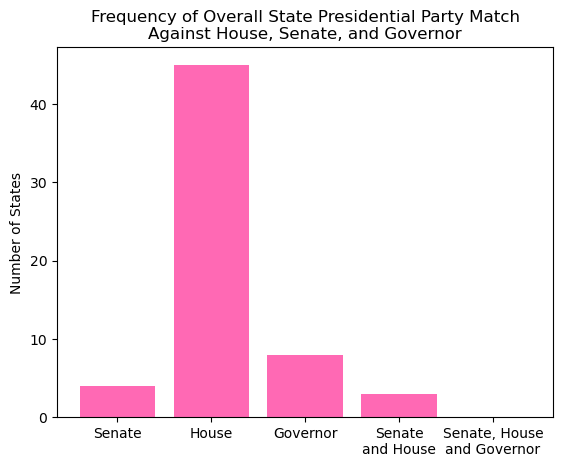

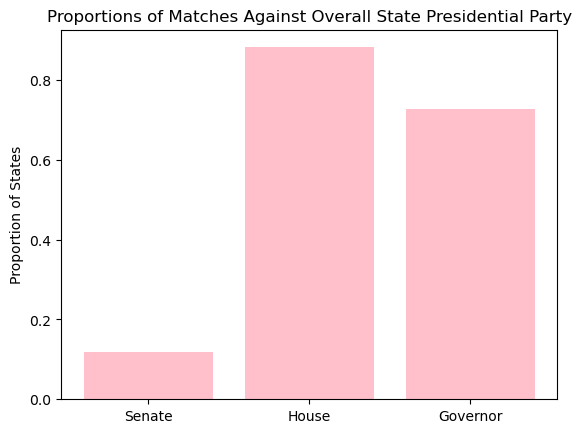

In [14]:
# Raw counts of number of matches 
categories = ["Senate", "House", "Governor", "Senate\nand House", "Senate, House\nand Governor"]
num_states = raw_counts 
#created from table above

plt.bar(x = categories, height = num_states, color = "hotpink")
plt.ylabel("Number of States")
plt.title("Frequency of Overall State Presidential Party Match\nAgainst House, Senate, and Governor")
plt.show()

#Proportions of matches among states that participated for each elected position
categories = ["Senate", "House", "Governor"]
proportions_state = [    
    len(merged.query("Presidential_Party == Senator_Party"))/len(df_senator["state"].unique()),
    len(merged.query("Presidential_Party == House_Majority"))/len(df_house["States"].unique()),
    len(merged.query("(Presidential_Party == Governor_Party)"))/len(df_governor["state"].unique())]

plt.bar(x = categories, height = proportions_state, color = "pink")
plt.ylabel("Proportion of States")
plt.title("Proportions of Matches Against Overall State Presidential Party")
plt.show()

### Discussion
For the most part, political parties were identical across presidential and house majority elections. A large proportion of states that did elect new governors for the 2020 cycle also had an identical political party to their presidential party. The frequency just appears lower due the limited governors elected. This information is consistent with what we'd expect in that states with a general political ideology will opt to elect leaders with identify in the same party. 

What stands out is the how many senators elected identified with political parties that were different than their state's presidential party. This could be due to other factors such as geography, economic standing, and education level of voters in the state. Future research could look into these variables and obtain a more detailed dataset. 